# Fase 1 — Recolección de datos y separación train/test

**TP1 — Regresión e Introducción a la Evaluación de Modelos**
Materia 72.75 — Aprendizaje Automático — ITBA

Cubre la consigna **2.1 (Separación de datos)** del enunciado.

---

## Qué se hace en esta fase, y qué explícitamente *no* se hace

| Sí | No |
|---|---|
| Leer el CSV desde la ruta local | Imputar valores |
| Verificar la integridad **estructural** del archivo | Eliminar outliers |
| Separar train y test | Escalar o codificar |
| Auditar que la separación sea limpia | Calcular medias, medianas o IQR |

La columna derecha no es un olvido: es el punto metodológico central del TP.
Todo lo que dependa de un **estadístico** de los datos se ajusta más adelante y
**usando sólo el train**.

In [1]:
# El notebook trabaja desde la raíz del repo para poder importar src/.
# (En VS Code esto ya lo garantiza .vscode/settings.json, pero dejarlo explícito
#  hace que el notebook funcione también al ejecutarlo desde la terminal.)
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.config import RANDOM_SEED, TARGET, TEST_SIZE, FIGURES_DIR
from src.data import (
    cargar_datos_crudos,
    separar_train_test,
    verificar_split,
    guardar_splits,
    COLUMNA_ESTRATIFICACION,
)

pd.set_option("display.width", 110)
print(f"Semilla del proyecto: {RANDOM_SEED} | Target: {TARGET}")

Semilla del proyecto: 42 | Target: charges


---

## 1. Carga del dataset

El dataset se lee **siempre** desde `data/raw/insurance.csv`. El pipeline nunca
descarga nada en tiempo de ejecución.

> **Por qué no usar `kagglehub`:** `dataset_download()` trae la *latest version*
> publicada. Si esa versión cambiara entre hoy y la defensa, los números de la
> presentación dejarían de reproducirse, y además el análisis dependería de tener
> internet. El CSV está versionado en el repositorio justamente para congelar los
> datos sobre los que se obtuvieron los resultados.

In [2]:
df = cargar_datos_crudos()

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1338 filas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.1 Verificación estructural

Esto **no es limpieza de datos**: no se modifica ni se descarta nada. Es un control
de que el archivo es el que esperamos (columnas correctas, tipos coherentes, cantidad
de filas conocida). `cargar_datos_crudos()` falla con un error explícito si el CSV
fuera reemplazado por otra versión, para que el problema aparezca acá y no cinco
fases después disfrazado de un resultado raro.

El diagnóstico completo de faltantes, duplicados y outliers —y las **decisiones**
sobre qué hacer con ellos— corresponde a la Fase 2, y se hará mirando sólo el train.

In [3]:
print("--- Tipos de dato ---")
print(df.dtypes.to_string())

print("\n--- Valores faltantes por columna ---")
print(df.isna().sum().to_string())

print(f"\n--- Filas exactamente duplicadas: {df.duplicated().sum()} ---")
display(df[df.duplicated(keep=False)])

--- Tipos de dato ---
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64

--- Valores faltantes por columna ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

--- Filas exactamente duplicadas: 1 ---


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Observaciones estructurales:**

- **No hay valores faltantes** en ninguna columna. El análisis formal de la consigna
  1.2 se documenta igual en la Fase 2, sobre el train.
- **Hay un par de filas exactamente idénticas** (índices 195 y 581). Se deja constancia
  ahora porque tiene una implicancia sobre el split: si una copia cayera en train y la
  otra en test, el modelo sería evaluado sobre un dato que ya vio durante el
  entrenamiento — una forma silenciosa de leakage. Más abajo se verifica que eso no ocurra.
- Los tipos son los esperados. Nota: en pandas 3.0 las columnas de texto tienen dtype
  `str` (no `object` como en pandas 2.x).

---

## 2. Por qué el split va acá y no después de limpiar

El enunciado numera *"1. Limpieza de datos"* antes de *"2.1 Separación de datos"*,
pero ese es el orden de **exposición** de las consignas, no el de **ejecución**.

La Clase 2 (slides 93–96) plantea explícitamente la pregunta *"¿Dónde realizarían la
separación train-test?"* y responde: inmediatamente después de la recolección, con la
advertencia literal:

> *"Cuidado con el data leakage. Si quitamos outliers e imputamos valores usando TODO
> el dataset, información que luego irá al test estará siendo usada para train."*

El mecanismo concreto: si imputáramos con la mediana del dataset completo, esa mediana
contiene información de las filas que van a ir al test. El modelo entrenaría con un
valor que resume, en parte, datos que se supone que nunca vio. El error de test dejaría
de ser una estimación honesta de cómo funciona el modelo con datos nuevos, y saldría
**optimistamente sesgado**.

Lo mismo vale para el IQR usado para detectar outliers, para la media y el desvío del
escalado, y para el target encoding de las categóricas.

---

## 3. ¿Qué proporción train/test?

La Clase 2 (slide 83) propone **60-20-20** como regla para datasets de tamaño
pequeño-mediano. Ese esquema reserva un *dev set* fijo para elegir modelo.

Acá se usa **80-20**, y el 20% de dev "desaparece" porque **la validación se hace con
k-fold sobre el train** (consigna 2.2), no con un holdout fijo. Es la propia
recomendación de la slide 85: para datasets pequeños, cross-validation *"nos permite
utilizar los datos de manera más eficiente"*. En vez de congelar 268 filas que sólo
sirven para elegir modelo, cada fila del train se usa para entrenar en 4 de los 5 folds
y para validar en 1.

El criterio de la slide 69 para el test es: no hace falta que sea tan grande como el
train, pero debe tener suficientes datos para representar la muestra.

In [4]:
n = len(df)
p_fumadores = (df[COLUMNA_ESTRATIFICACION] == "yes").mean()

filas = []
for t in (0.15, 0.20, 0.25, 0.30):
    n_te = int(round(n * t))
    filas.append({
        "test_size": f"{t:.0%}",
        "n_train": n - n_te,
        "n_test": n_te,
        "fumadores_en_test": int(round(n_te * p_fumadores)),
    })

pd.DataFrame(filas)

,test_size,n_train,n_test,fumadores_en_test
0,15%,1137,201,41
1,20%,1070,268,55
2,25%,1004,334,68
3,30%,937,401,82


**Decisión: `test_size = 0.20`.**

- Con 15% el test queda en 201 filas y sólo ~41 fumadores: el subgrupo que domina el
  error quedaría estimado sobre muy pocos casos.
- Con 30% el test tendría 401 filas, pero le saca 133 filas al train sin ganar nada
  relevante en precisión de la estimación.
- **20% deja 1070 filas de train y 268 de test (~55 fumadores)**, que es un equilibrio
  razonable entre tener con qué entrenar y tener con qué estimar el error de forma estable.

---

## 4. ¿Conviene estratificar por `smoker`?

Primero, el motivo por el cual la pregunta tiene sentido: `smoker` parte el target en
dos poblaciones casi disjuntas.

In [5]:
resumen_smoker = df.groupby(COLUMNA_ESTRATIFICACION)[TARGET].agg(
    ["count", "mean", "std", "min", "max"]
)
resumen_smoker["proporcion"] = resumen_smoker["count"] / len(df)
resumen_smoker.round(2)

,count,mean,std,min,max,proporcion
smoker,,,,,,
no,1064,8434.27,5993.78,1121.87,36910.61,0.8
yes,274,32050.23,11541.55,12829.46,63770.43,0.2


Un fumador cuesta en promedio **~3.8 veces** más que un no fumador, y los fumadores
son sólo el **20.5%** de la muestra. Con una minoría tan influyente, la pregunta es:
¿cuánto puede desbalancearse el test si el sorteo es puramente aleatorio?

En vez de argumentarlo en abstracto, se mide: se simulan 1000 splits con semillas
distintas, con y sin estratificación.

In [6]:
def simular_splits(estratificar, n_sim=1000):
    props, medias = [], []
    for s in range(n_sim):
        _, te = train_test_split(
            df,
            test_size=TEST_SIZE,
            random_state=s,
            stratify=df[COLUMNA_ESTRATIFICACION] if estratificar else None,
        )
        props.append((te[COLUMNA_ESTRATIFICACION] == "yes").mean())
        medias.append(te[TARGET].mean())
    return np.array(props), np.array(medias)

resultados = []
for estratificar in (False, True):
    props, medias = simular_splits(estratificar)
    resultados.append({
        "estrategia": "Estratificado" if estratificar else "Aleatorio simple",
        "%fum_min": f"{props.min():.2%}",
        "%fum_max": f"{props.max():.2%}",
        "%fum_desvio": f"{props.std():.2%}",
        "media_charges_min": f"{medias.min():,.0f}",
        "media_charges_max": f"{medias.max():,.0f}",
        "media_charges_desvio": f"{medias.std():,.0f}",
    })

print(f"Proporcion de fumadores en la poblacion: {p_fumadores:.2%}\n")
pd.DataFrame(resultados).set_index("estrategia").T

Proporcion de fumadores en la poblacion: 20.48%



estrategia,Aleatorio simple,Estratificado
%fum_min,12.69%,20.52%
%fum_max,26.87%,20.52%
%fum_desvio,2.05%,0.00%
media_charges_min,"10,684","12,083"
media_charges_max,"15,605","14,631"
media_charges_desvio,630,411


**Lectura del experimento:**

- Con split **aleatorio simple**, la proporción de fumadores en el test va de **12.7% a
  26.9%** según la semilla. En cantidades absolutas: entre 34 y 72 fumadores sobre 268.
  Dos semillas distintas producen conjuntos de test sustancialmente diferentes.
- Con split **estratificado**, la proporción es 20.5% siempre, con desvío cero por construcción.
- La consecuencia práctica está en la última fila: el desvío de la media de `charges` del
  test baja de **~630 a ~411**, es decir **un 35% menos de variabilidad** en el conjunto
  sobre el que se va a reportar el RMSE.

**Decisión: estratificar por `smoker`.**

El argumento de fondo es que sin estratificar, una parte del RMSE de test mediría *qué
tan afortunado fue el sorteo* en lugar de *qué tan bueno es el modelo*. La slide 69 pide
que el test "represente los datos reales en los que el modelo se usará"; forzar la misma
proporción de fumadores es exactamente eso.

> **Aclaración para la defensa:** estratificar usa la columna `smoker`, no el target.
> No es leakage: no se estima ningún parámetro con los datos, sólo se organiza el sorteo
> para que ambos conjuntos tengan la misma composición. La regla que hay que respetar
> —y se respeta— es que ningún **estadístico** calculado sobre el test influya en el
> entrenamiento.

---

## 5. Split definitivo

Se ejecuta con la semilla del proyecto (`RANDOM_SEED = 42`, definida en `src/config.py`).
Fijar la semilla es lo que hace que el resultado mostrado en la defensa sea exactamente
el que se obtiene al re-ejecutar el código.

In [7]:
train, test = separar_train_test(df)

print(f"Train: {train.shape[0]:5d} filas ({train.shape[0]/len(df):.1%})")
print(f"Test : {test.shape[0]:5d} filas ({test.shape[0]/len(df):.1%})")

Train:  1070 filas (80.0%)
Test :   268 filas (20.0%)


### 5.1 Auditoría del split

Tres controles automáticos. Los dos primeros son de integridad; el tercero es el que
protege contra el leakage del par de filas duplicadas detectado en la sección 1.1.

In [8]:
chequeos = verificar_split(train, test)

for k, v in chequeos.items():
    print(f"{k:32s}: {v:,.4f}" if isinstance(v, float) else f"{k:32s}: {v}")

n_train                         : 1070
n_test                          : 268
prop_test                       : 0.2003
solapamiento_indices            : 0
filas_identicas_compartidas     : 0
prop_fumadores_train            : 0.2047
prop_fumadores_test             : 0.2052
media_target_train              : 13,285.1119
media_target_test               : 13,211.7732


- `solapamiento_indices = 0` → ninguna fila quedó en ambos conjuntos.
- `filas_identicas_compartidas = 0` → **las dos copias de la fila duplicada cayeron ambas
  en train**, así que el test no contiene ningún registro idéntico a uno visto en
  entrenamiento. El duplicado se tratará en la Fase 2, dentro del train, donde
  corresponde.
- Las proporciones de fumadores en train y test coinciden hasta la centésima, como era
  de esperar por la estratificación.

### 5.2 ¿Se parecen train y test?

Un control de sanidad: la estratificación garantiza el balance de `smoker`, pero conviene
verificar que el resto de las variables no haya quedado desbalanceado por casualidad.

In [9]:
num_cols = ["age", "bmi", "children", TARGET]

comparacion = pd.DataFrame({
    "train_media": train[num_cols].mean(),
    "test_media": test[num_cols].mean(),
    "train_desvio": train[num_cols].std(),
    "test_desvio": test[num_cols].std(),
})
comparacion["dif_medias_%"] = (
    100 * (comparacion["test_media"] - comparacion["train_media"]) / comparacion["train_media"]
)
comparacion.round(2)

,train_media,test_media,train_desvio,test_desvio,dif_medias_%
age,39.13,39.51,14.04,14.12,0.96
bmi,30.77,30.24,6.05,6.30,-1.70
children,1.11,1.05,1.21,1.19,-5.24
charges,13285.11,13211.77,12100.85,12169.04,-0.55


In [10]:
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    prop = pd.DataFrame({
        "train": train[col].value_counts(normalize=True),
        "test": test[col].value_counts(normalize=True),
    })
    print(f"--- {col} ---")
    print((100 * prop).round(2).to_string())
    print()

--- sex ---
        train   test
sex                 
female  49.16  50.75
male    50.84  49.25

--- smoker ---
        train   test
smoker              
no      79.53  79.48
yes     20.47  20.52

--- region ---
           train   test
region                 
northeast  24.49  23.13
northwest  24.30  24.25
southeast  27.20  27.24
southwest  24.02  25.37



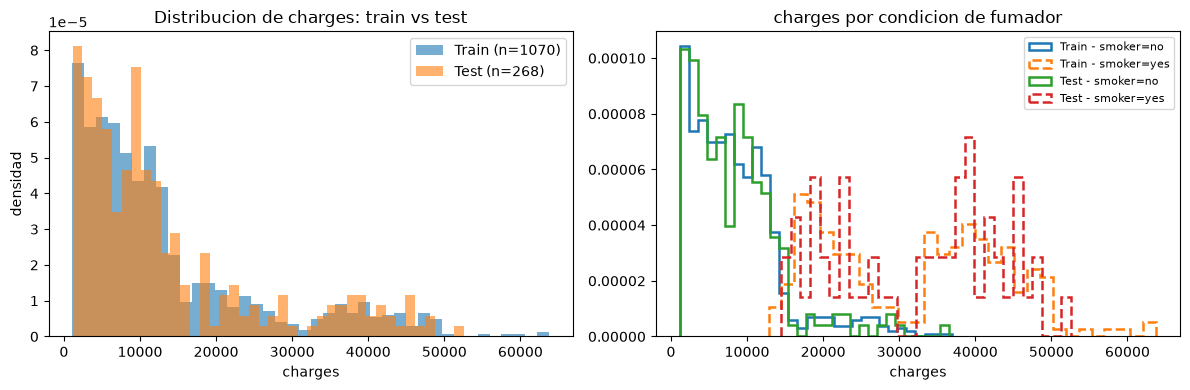

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train[TARGET], bins=40, density=True, alpha=0.6, label=f"Train (n={len(train)})")
axes[0].hist(test[TARGET], bins=40, density=True, alpha=0.6, label=f"Test (n={len(test)})")
axes[0].set_title("Distribucion de charges: train vs test")
axes[0].set_xlabel("charges")
axes[0].set_ylabel("densidad")
axes[0].legend()

for i, (nombre, conjunto) in enumerate([("Train", train), ("Test", test)]):
    for fuma, estilo in [("no", "-"), ("yes", "--")]:
        sub = conjunto.loc[conjunto[COLUMNA_ESTRATIFICACION] == fuma, TARGET]
        axes[1].hist(sub, bins=30, density=True, histtype="step", linestyle=estilo,
                     linewidth=1.8, label=f"{nombre} - smoker={fuma}")
axes[1].set_title("charges por condicion de fumador")
axes[1].set_xlabel("charges")
axes[1].legend(fontsize=8)

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "01_distribucion_charges_train_test.png", dpi=150, bbox_inches="tight")
plt.show()

Las medias y desvíos de las variables numéricas difieren en pocos puntos porcentuales,
las proporciones de las categóricas son similares, y el panel derecho muestra la
estructura **bimodal** del target: fumadores y no fumadores forman dos poblaciones
separadas, y esa separación se conserva en ambos conjuntos.

Ese panel derecho, además, adelanta la discusión de la Fase 2: los valores altos de
`charges` no son ruido ni errores de carga, son fumadores. Es la razón por la que aplicar
un criterio de outliers por IQR sobre el target a ciegas sería un error.

---

## 6. Persistencia de los splits

Se guardan en `data/processed/`, conservando el índice original del CSV para poder
rastrear cada fila hasta su origen.

A partir de la Fase 2, **ningún notebook vuelve a abrir el CSV crudo**: todos entran por
`cargar_splits()`. Así es estructuralmente imposible recalcular por error un estadístico
sobre el dataset completo.

In [12]:
guardar_splits(train, test)

train_recargado, test_recargado = __import__("src.data", fromlist=["cargar_splits"]).cargar_splits()
print(f"train.csv -> {train_recargado.shape}")
print(f"test.csv  -> {test_recargado.shape}")
print(f"Indices preservados: {(train_recargado.index == train.index).all()}")

train.csv -> (1070, 7)
test.csv  -> (268, 7)
Indices preservados: True


> Los archivos de `data/processed/` están en el `.gitignore`: no se versionan porque se
> regeneran de forma determinista con `python -m src.data`. Lo que garantiza la
> reproducibilidad es la semilla fijada en `src/config.py` más el CSV crudo versionado,
> no los archivos derivados.

---

## Conclusiones de la Fase 1

| Decisión | Valor | Justificación |
|---|---|---|
| Momento del split | Inmediatamente tras la carga | Evitar data leakage (Clase 2, slides 93–96) |
| Proporción | 80% train / 20% test | 1070 / 268 filas; el dev fijo se reemplaza por k-fold sobre train |
| Estratificación | Por `smoker` | Sin ella, la proporción de fumadores en test varía entre 12.7% y 26.9% según la semilla |
| Semilla | 42 (en `src/config.py`) | Reproducibilidad del resultado en la defensa |
| Duplicados | Detectados, no tratados aún | Ambas copias cayeron en train; se resuelven en Fase 2 |

**Estado del test set:** separado y guardado. No se vuelve a mirar hasta la Fase 6.

**Siguiente:** Fase 2 — Análisis exploratorio sobre el train (consignas 1.2 y 1.3).